# 01 — Exploratory Data Analysis
Understand the structure, distributions, and patterns in the UPI transaction dataset.

In [13]:
import sys, os
sys.path.append(os.path.dirname(os.getcwd()))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import config
sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load Data

In [3]:
X_train = pd.read_csv(config.X_TRAIN_PATH)
X_test  = pd.read_csv(config.X_TEST_PATH)
y_train = pd.read_csv(config.Y_TRAIN_PATH).squeeze()
y_test  = pd.read_csv(config.Y_TEST_PATH).squeeze()
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
X_train.head()

X_train shape: (21114, 18)
X_test shape : (5279, 18)


,amount,session_duration,receiver_transaction_history,transaction_amount_vs_sender_history,geographic_disparity,transaction_time_of_day,time_between_link_click_and_transaction,input_timing_consistency,keyboard_input_speed,input_pause_patterns,screen_active_time,geographic_location_vs_ip,background_data_usage,pin_entry_speed,request_amount_roundness,request_acceptance_rate,time_to_respond_to_request,user_id_freq
0,6.474054,-0.978482,-1.276878,4.807647,0.914343,-0.004340,-0.156998,0.507576,1.566618,-0.481381,-0.128521,0.924331,-1.033755,-0.035114,-0.095119,-0.163037,-0.155435,-0.201819
1,-0.655240,-0.273609,1.004131,-0.277018,-0.428740,1.266485,-0.156998,0.553330,-1.208880,-0.431659,1.140422,-0.423848,-0.106695,-0.267214,-0.095275,-0.163037,-0.155435,5.908894
2,-0.347576,-1.616224,-1.308559,-0.308773,0.884467,-0.569151,8.881270,-3.663200,-1.867483,2.373832,-1.780161,-1.653605,1.785394,0.637016,0.286630,-0.163037,-0.155435,-0.609200
3,-0.270866,0.610278,-0.136374,-0.181317,1.077601,-0.992760,-0.156998,0.637364,0.859190,0.115946,0.918861,1.088208,-0.632827,0.079624,-0.094807,-0.163037,-0.155435,-1.016581
4,0.090714,-1.302947,-0.991752,-0.070840,-0.374300,-0.710354,-0.156998,0.403871,-0.871140,-0.416310,1.549975,-0.369201,0.242346,-0.749352,-0.095343,-0.163037,-0.155435,-0.201819


## 2. Basic Statistics

In [4]:
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
amount,21114.0,-8.783350e-17,1.000024,-0.823640,-0.427003,-0.206490,0.065084,7.879624
session_duration,21114.0,-4.004669e-17,1.000024,-1.750485,-0.821844,-0.061029,0.778105,4.906644
receiver_transaction_history,21114.0,1.103808e-16,1.000024,-1.340240,-0.991752,-0.073012,0.877408,1.827829
transaction_amount_vs_sender_history,21114.0,6.797842e-17,1.000024,-0.370974,-0.275056,-0.201853,-0.056390,38.236514
geographic_disparity,21114.0,1.561484e-16,1.000024,-2.120731,-0.783782,0.004471,0.781395,2.109019
transaction_time_of_day,21114.0,1.029772e-16,1.000024,-1.557571,-0.851557,-0.004340,0.842876,1.690093
time_between_link_click_and_transaction,21114.0,2.019161e-18,1.000024,-0.156998,-0.156998,-0.156998,-0.156998,9.192935
input_timing_consistency,21114.0,-3.843136e-16,1.000024,-5.635754,-0.383379,0.130040,0.657916,1.181449
keyboard_input_speed,21114.0,-3.634490e-17,1.000024,-2.555849,-0.787806,0.028765,0.842420,1.660352
input_pause_patterns,21114.0,-1.746574e-16,1.000024,-0.958148,-0.560052,-0.161147,0.270583,6.854680


## 3. Missing Values

In [5]:
missing = X_train.isnull().sum()
print(missing[missing > 0] if missing.any() else 'No missing values.')

No missing values.


## 4. Class Distribution

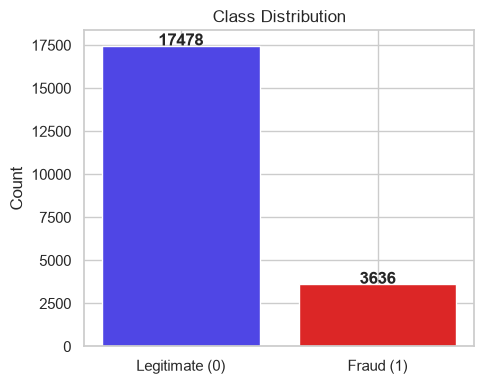

Fraud rate: 17.22%


In [6]:
counts = y_train.value_counts()
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(['Legitimate (0)', 'Fraud (1)'], counts.values, color=['#4f46e5', '#dc2626'])
ax.set_title('Class Distribution')
ax.set_ylabel('Count')
for i, v in enumerate(counts.values):
    ax.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout()
os.makedirs(config.FIGURES_DIR, exist_ok=True)
plt.savefig(os.path.join(config.FIGURES_DIR, 'class_distribution.png'), dpi=150)
plt.show()
print(f'Fraud rate: {counts[1]/counts.sum()*100:.2f}%')

## 5. Feature Distributions by Class

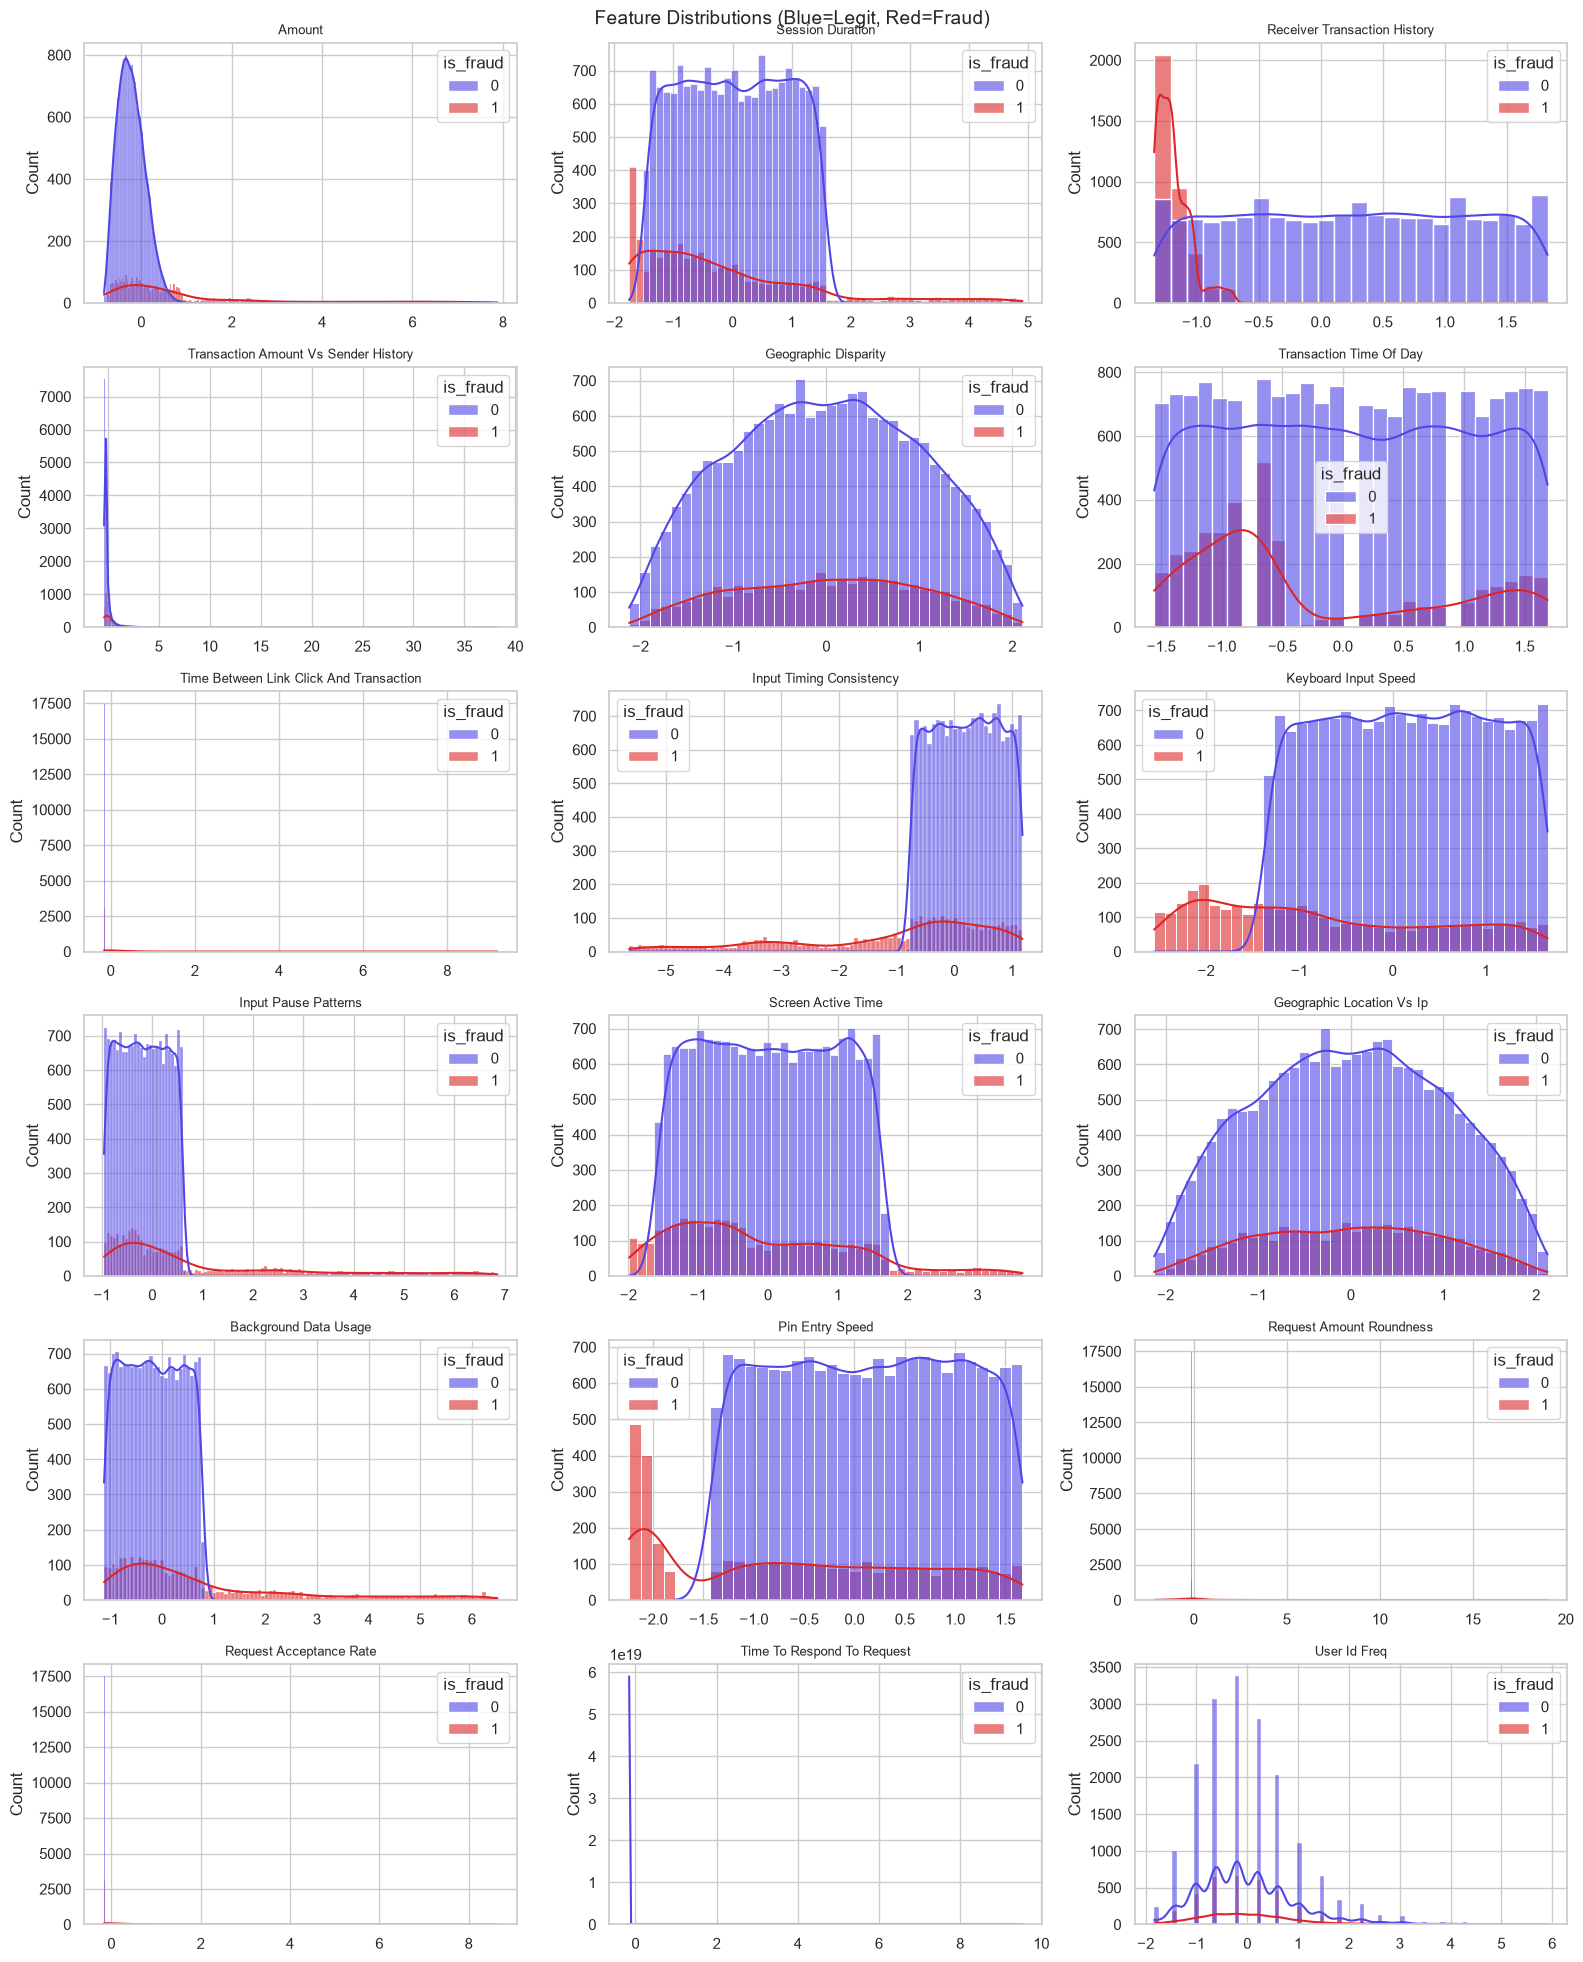

In [14]:
df = X_train.copy()
df['is_fraud'] = y_train.values
fig, axes = plt.subplots(6, 3, figsize=(16, 20))
axes = axes.flatten()
for i, col in enumerate(config.FEATURE_COLUMNS):
    sns.histplot(data=df, x=col, hue='is_fraud', kde=True, ax=axes[i],
                 palette={0: '#4f46e5', 1: '#dc2626'}, alpha=0.6)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=9)
    axes[i].set_xlabel('')
for ax in axes[len(config.FEATURE_COLUMNS):]:
    ax.set_visible(False)
plt.suptitle('Feature Distributions (Blue=Legit, Red=Fraud)', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_DIR, 'feature_distributions.png'), dpi=150)
plt.show()

## 6. Correlation Heatmap

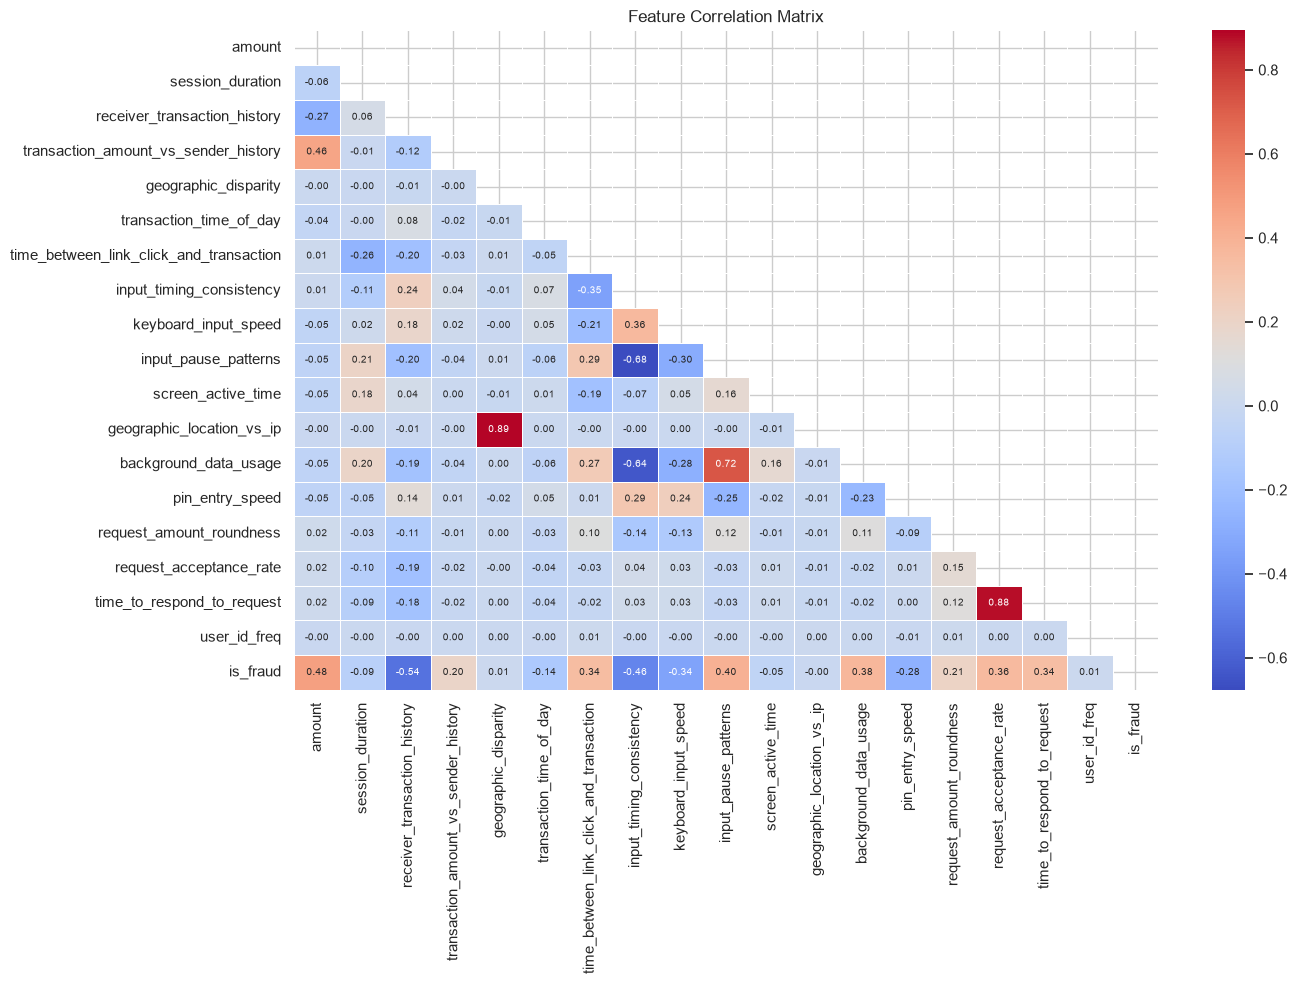

In [10]:
plt.figure(figsize=(14, 10))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_DIR, 'correlation_heatmap.png'), dpi=150)
plt.show()

## 7. Box Plots — Key Features

C:\Users\sahuk\AppData\Local\Temp\ipykernel_33976\2589233130.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_fraud', y=col, ax=axes[i//3][i%3],


ValueError: The palette dictionary is missing keys: {'0', '1'}

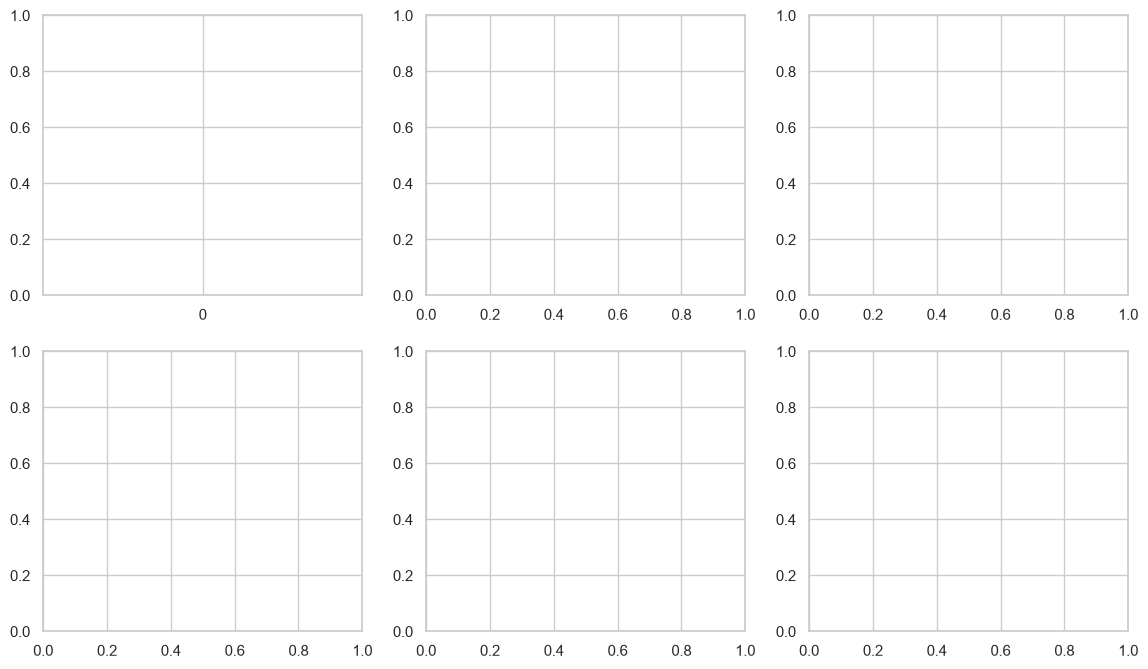

In [15]:
top = ['amount', 'session_duration', 'pin_entry_speed',
       'keyboard_input_speed', 'geographic_disparity', 'background_data_usage']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for i, col in enumerate(top):
    sns.boxplot(data=df, x='is_fraud', y=col, ax=axes[i//3][i%3],
                palette={0: '#4f46e5', 1: '#dc2626'})
    axes[i//3][i%3].set_title(col.replace('_', ' ').title())
plt.suptitle('Key Feature Box Plots by Class', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(config.FIGURES_DIR, 'boxplots.png'), dpi=150)
plt.show()